# ARoF ETDKAN-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent.parent)

sys.path.append(project_path)

In [2]:
import pickle
import optuna
import numpy as np
import torch as th
import matplotlib.pyplot as plt

from functools                import partial
from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, finddelay, decimate, upsample, clockSamplingInterp
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W

from dpd.nn                   import KAN_training
from dpd.utils                import power_amplifier, calcACLR
from dpd.torchUtils           import fitFilterNN
from dpd.optuna_tasks         import objective_dpd, get_pareto, getTrialParam

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

In [4]:
symbTx    = np.loadtxt(project_path + r"\examples\transmittedSignal\symbTx.txt", dtype = np.complex64)
symbRx    = np.loadtxt(project_path + r"\examples\transmittedSignal\symbRx.txt", dtype = np.complex64)
sigTx_ref = np.loadtxt(project_path + r"\examples\transmittedSignal\sigTx.txt", dtype = np.complex64)
sigRx_PA  = np.loadtxt(project_path + r"\examples\transmittedSignal\sigRx_PA.txt", dtype = np.complex64)

In [5]:
with open(project_path + r"\examples\transmittedSignal\paramOFDM.pkl", 'rb') as f:
    paramOFDM = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramRF.pkl", 'rb') as f:
    paramRF = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramMZM.pkl", 'rb') as f:
    paramMZM = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramChannel.pkl", 'rb') as f:
    paramChannel = pickle.load(f)
    f.close()

with open(project_path + r"\examples\transmittedSignal\paramPD.pkl", 'rb') as f:
    paramPD = pickle.load(f)
    f.close()

### 1 - Geração do Sinal OFDM

In [6]:
# Param RoF
paramRoF = parameters()

paramRoF.paramOFDM    = paramOFDM
paramRoF.paramMZM     = paramMZM
paramRoF.paramChannel = paramChannel
paramRoF.paramRF      = paramRF
paramRoF.paramPD      = paramPD

### 3 Preparação do conjunto de dados de treinamento

In [7]:
SpS_DPD = 4
SpS = paramOFDM.SpS
Rs  = paramOFDM.Rs
Fs  = paramOFDM.Fs

device = 'cuda'

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_DPD

numtaps = 4096
hlp = firwin(numtaps, SpS_DPD*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx_ref)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

In [8]:
sigRef = th.from_numpy(sigRef).to(device).type(th.complex64)
sigIn  = th.from_numpy(sigIn).to(device).type(th.complex64)

train_data = parameters()
train_data.sigRef = sigRef
train_data.sigIn  = sigIn
train_data.symbTx = symbTx

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [9]:
paramDPD = parameters()

paramDPD.model = "ETDKAN"
paramDPD.N = 50_000

paramDPD.divByL = 1
paramDPD.trainTestFrac = 0.75
paramDPD.shuffle = False

paramDPD.includeMemory = True
paramDPD.augment = False

paramDPD.device = device
paramDPD.pgrsBar = False
paramDPD.directLearn = False

paramDPD.batch_size = 1_000
paramDPD.lr = 5e-3
paramDPD.epochs = 100

paramDPD.SpS_DPD = SpS_DPD
paramDPD.Ntaps = 4
paramDPD.K = 0

paramDPD.k = 2
paramDPD.grid = 5
paramDPD.seed = 0
paramDPD.layers = [paramDPD.Ntaps, 5, paramDPD.Ntaps]

paramDPD.RoF_model = None
paramDPD.envelope  = True

paramDPD.pruning_epochs = []
paramDPD.symb = True

In [10]:
n_trials  = 500
n_studies = np.array([1])
timeout   = 60*60*25
save      = True

search_space = {
    'N1': [i for i in range(1, 6)],
    'Ntaps': [i for i in range(2, 9, 2)],
    'grid': [2, 3, 4, 5, 6],
    'k': [2, 3, 4, 5, 6]
}

metrics = [ ["EVM", "NFLOPs"],
            ["ACLR", "NFLOPs"] ]

for i, std in enumerate(n_studies):

    description = f"""
    sampler: GridSampler 
    ntrials: {n_trials} 
    
    Hyperparameters range: 
    Ntaps: 2 - 8 (step of 2) 
    k: 2 - 6 
    grid: 2 - 6
    N1: 1 - 5 
    
    Obs.: {metrics[i][0]} and NFLOP as objective functions
    """
    
    with open(file_path + f"\\study{n_studies[i]}\\description.txt", "w") as description_file:
        description_file.write(description)
    
    objective_ILA = partial(objective_dpd, train_data = train_data, paramRoF = paramRoF, paramDPD = paramDPD, metrics = metrics[i], 
                            model_path = file_path + f"\\study{std}\\models")
    
    print(f"Study {std}:")
    #study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.GridSampler(search_space))
    study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_N1     = np.zeros(n_complete_trials)
    study_Ntaps  = np.zeros(n_complete_trials)
    study_k      = np.zeros(n_complete_trials)
    study_grid   = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    study_ACLR   = np.zeros(n_complete_trials)
    study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params    = complete_trials[j].params
        study_EVM[j]     = complete_trials[j].values[0]
        study_ACLR[j]    = complete_trials[j].values[1]
        study_NFLOPs[j]  = complete_trials[j].values[1]
        
        study_N1[j]    = trials_params["N1"]
        study_Ntaps[j] = trials_params["Ntaps"]
        study_k[j]     = trials_params["k"]
        study_grid[j]  = trials_params["grid"]
    
    if save:
        np.savetxt(file_path + f'\\study{std}\\parameters\\N1.txt', study_N1, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\Ntaps.txt', study_Ntaps, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\k.txt', study_k, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\parameters\\grid.txt', study_grid, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\NFLOps.txt', study_NFLOPs, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\study{std}\\results\\EVM.txt', study_EVM, fmt = '%f')

Study 1:


  0%|          | 0/500 [00:00<?, ?it/s]

In [11]:
n_trials = 435

In [12]:
study_EVM         = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(n_trials) ])
study_NFLOPs_EVM  = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(n_trials) ])

study_ACLR        = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{i}.txt")[1] for i in range(n_trials) ]) # np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[1] for j in range(n_trials) ])
study_NFLOPs_ACLR = np.array([ np.loadtxt(file_path + f"\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(n_trials) ])

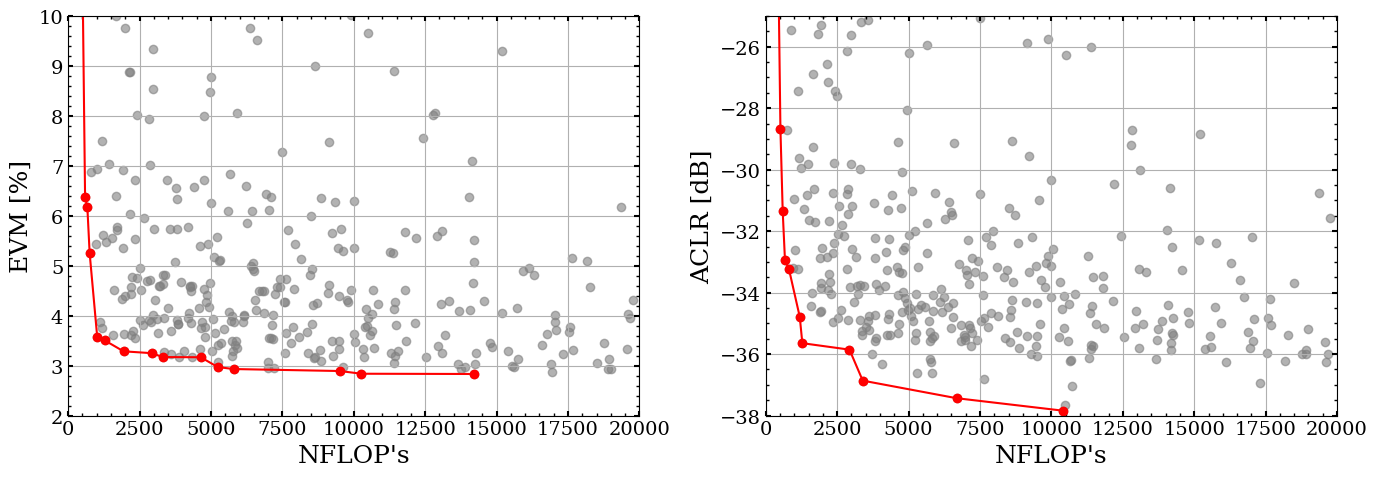

In [13]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

# EVM vs NFLOPs
pareto_solutions_evm, pareto_trials_evm = get_pareto(study_EVM, study_NFLOPs_EVM, n_trials)

axs[0].scatter(study_NFLOPs_EVM, study_EVM, color = "gray", alpha = 0.6)
axs[0].plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = "r")

axs[0].set_xlim(0, 20e3)
axs[0].set_ylim(2., 10)
axs[0].set_xlabel("NFLOP's", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

# ACLR vs NFLOPs
pareto_solutions_aclr, pareto_trials_aclr = get_pareto(study_ACLR, study_NFLOPs_ACLR, n_trials)

axs[1].scatter(study_NFLOPs_ACLR, study_ACLR, color = "gray", alpha = 0.6)
axs[1].plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = "r")

axs[1].set_xlim(0, 20e3)
axs[1].set_ylim(-38, -25)
axs[1].set_xlabel("NFLOP's", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")

In [14]:
# Pareto Trials - EVM vs NFLOPs

for i, trial in enumerate(pareto_trials_evm):
    print(f"Trial {trial}: EVM = {study_EVM[trial]:.3f} %, NFLOPs = {study_NFLOPs_EVM[trial]}") 

Trial 5: EVM = 6.168 %, NFLOPs = 672.0
Trial 66: EVM = 6.382 %, NFLOPs = 592.0
Trial 81: EVM = 3.172 %, NFLOPs = 3308.0
Trial 120: EVM = 3.168 %, NFLOPs = 4640.0
Trial 131: EVM = 2.833 %, NFLOPs = 14204.0
Trial 149: EVM = 10.341 %, NFLOPs = 512.0
Trial 157: EVM = 5.251 %, NFLOPs = 752.0
Trial 220: EVM = 3.580 %, NFLOPs = 1016.0
Trial 241: EVM = 3.249 %, NFLOPs = 2930.0
Trial 291: EVM = 2.892 %, NFLOPs = 9506.0
Trial 292: EVM = 3.287 %, NFLOPs = 1938.0
Trial 306: EVM = 2.838 %, NFLOPs = 10268.0
Trial 356: EVM = 2.932 %, NFLOPs = 5804.0
Trial 359: EVM = 3.505 %, NFLOPs = 1280.0
Trial 373: EVM = 12.048 %, NFLOPs = 432.0
Trial 434: EVM = 2.971 %, NFLOPs = 5240.0


In [16]:
trial_number = 306
param_trial = getTrialParam(trial_number, ["Ntaps", "N1", "k", "grid"], file_path + f"\study{1}\parameters")

Ntaps = 4.0
N1 = 3.0
k = 5.0
grid = 2.0


In [17]:
# Pareto Trials - ACLR vs NFLOPs

for i, trial in enumerate(pareto_trials_aclr):
    print(f"Trial {trial}: ACLR = {study_ACLR[trial]:.3f} dB, NFLOPs = {study_NFLOPs_ACLR[trial]}") 

Trial 5: ACLR = -32.954 dB, NFLOPs = 672.0
Trial 66: ACLR = -31.352 dB, NFLOPs = 592.0
Trial 77: ACLR = -33.231 dB, NFLOPs = 810.0
Trial 93: ACLR = -34.782 dB, NFLOPs = 1188.0
Trial 122: ACLR = -37.840 dB, NFLOPs = 10402.0
Trial 147: ACLR = -37.434 dB, NFLOPs = 6678.0
Trial 149: ACLR = -28.663 dB, NFLOPs = 512.0
Trial 241: ACLR = -35.855 dB, NFLOPs = 2930.0
Trial 359: ACLR = -35.645 dB, NFLOPs = 1280.0
Trial 373: ACLR = -22.899 dB, NFLOPs = 432.0
Trial 402: ACLR = -36.863 dB, NFLOPs = 3394.0


In [18]:
trial_number = 122
param_trial = getTrialParam(trial_number, ["Ntaps", "N1", "k", "grid"], file_path + f"\study{1}\parameters")

Ntaps = 4.0
N1 = 2.0
k = 6.0
grid = 3.0
